# System rekomendacji win
### Porównanie modeli: NCF, Gradient Boosting, Random Forest, RP3β

## 1. Importy i konfiguracja

In [17]:
import sys
import os
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

print(sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

c:\Users\Filip\wine_pc\wine-recommender\.venv\Scripts\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060
Using device: cuda


## 2. Wczytanie i podział danych

In [18]:
df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')
df = df[["Rating", "UserID", "WineID", "Date"]]
df.sort_values("Date", ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train = train_df[["UserID", "WineID", "Date"]]
y_train = train_df["Rating"]
X_test  = test_df[["UserID", "WineID", "Date"]].copy()
y_test  = test_df["Rating"]

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

C:\Users\Filip\AppData\Local\Temp\ipykernel_6248\2572918404.py:1: DtypeWarning: Columns (0: Vintage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')


Train size: 120000, Test size: 30000


## 3. Mapowanie użytkowników i win na indeksy

In [19]:
users    = X_train['UserID'].unique()
wines    = X_train['WineID'].unique()
user2_id = {u: i for i, u in enumerate(users)}
wine2_id = {w: i for i, w in enumerate(wines)}

X_train = X_train.copy()
X_train['user_idx'] = X_train['UserID'].map(user2_id)
X_train['wine_idx'] = X_train['WineID'].map(wine2_id)
X_train.dropna(inplace=True)
y_train = y_train.loc[X_train.index]

X_test['user_idx'] = X_test['UserID'].map(user2_id)
X_test['wine_idx'] = X_test['WineID'].map(wine2_id)

# usuwanie cold-start (użytkownicy/wina spoza train)
mask = X_test['user_idx'].notna() & X_test['wine_idx'].notna()
X_test_clean = X_test[mask].copy()
y_test_clean = y_test[mask].copy()

for col in ['user_idx', 'wine_idx']:
    X_train[col]      = X_train[col].astype(int)
    X_test_clean[col] = X_test_clean[col].astype(int)

num_users = len(user2_id)
num_wines = len(wine2_id)
print(f"Liczba użytkowników: {num_users}, Liczba win: {num_wines}")
print(f"Cold-start usunięto: {(~mask).sum()} rekordów")

Liczba użytkowników: 10357, Liczba win: 1000
Cold-start usunięto: 1800 rekordów


## 4. Konwersja do tensorów i DataLoader

In [51]:
X_user_train = torch.tensor(X_train['user_idx'].values, dtype=torch.long)
X_wine_train = torch.tensor(X_train['wine_idx'].values, dtype=torch.long)
y_train_t    = torch.tensor(y_train.values, dtype=torch.float32)

X_user_test = torch.tensor(X_test_clean['user_idx'].values, dtype=torch.long)
X_wine_test = torch.tensor(X_test_clean['wine_idx'].values, dtype=torch.long)
y_test_t    = torch.tensor(y_test_clean.values, dtype=torch.float32)

batch_size    = 2048
train_loader  = DataLoader(TensorDataset(X_user_train, X_wine_train, y_train_t),
                           batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=2)
test_loader   = DataLoader(TensorDataset(X_user_test, X_wine_test, y_test_t),
                           batch_size=batch_size, pin_memory=True, num_workers=2)

## 5. Definicja metryk

In [52]:
def calculate_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def precision_at_k(y_true, y_pred, k=10, threshold=4.0):
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    return np.sum(y_true[sorted_indices] >= threshold) / k

def recall_at_k(y_true, y_pred, k=10, threshold=4.0):
    sorted_indices   = np.argsort(y_pred)[::-1][:k]
    total_relevant   = np.sum(y_true >= threshold)
    relevant_in_topk = np.sum(y_true[sorted_indices] >= threshold)
    return relevant_in_topk / total_relevant if total_relevant > 0 else 0

def ndcg_at_k(y_true, y_pred, k=10):
    def dcg_at_k(r, k):
        r = np.asarray(r, dtype=np.float64)[:k]
        return np.sum(r / np.log2(np.arange(2, r.size + 2))) if r.size else 0.
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    ideal_indices  = np.argsort(y_true)[::-1][:k]
    ideal_dcg      = dcg_at_k(y_true[ideal_indices], k)
    return dcg_at_k(y_true[sorted_indices], k) / ideal_dcg if ideal_dcg > 0 else 0

def calculate_ranking_metrics_per_user(X_test_df, y_test_array, y_pred_array, k=10):
    X_test_df = X_test_df.copy()
    X_test_df['y_true'] = y_test_array
    X_test_df['y_pred'] = y_pred_array

    precision_scores, recall_scores, ndcg_scores = [], [], []

    for user_id in X_test_df['user_idx'].unique():
        user_data = X_test_df[X_test_df['user_idx'] == user_id]
        if len(user_data) < k:
            continue
        y_true_user = user_data['y_true'].values
        y_pred_user = user_data['y_pred'].values
        precision_scores.append(precision_at_k(y_true_user, y_pred_user, k))
        recall_scores.append(recall_at_k(y_true_user, y_pred_user, k))
        ndcg_scores.append(ndcg_at_k(y_true_user, y_pred_user, k))

    return {
        f'Precision@{k}': np.mean(precision_scores),
        f'Recall@{k}':    np.mean(recall_scores),
        f'NDCG@{k}':      np.mean(ndcg_scores)
    }

def calculate_coverage(model, user2_id, wine2_id, device, threshold=3.5):
    model.eval()
    recommended_wines = set()
    with torch.no_grad():
        sample_users = np.random.choice(list(user2_id.values()),
                                        min(100, len(user2_id)), replace=False)
        for user_idx in sample_users:
            users_tensor = torch.tensor([user_idx] * len(wine2_id), dtype=torch.long, device=device)
            wines_tensor = torch.tensor(list(wine2_id.values()), dtype=torch.long, device=device)
            predictions  = model(users_tensor, wines_tensor).squeeze().cpu().numpy()
            recommended_wines.update(np.where(predictions >= threshold)[0])
    return len(recommended_wines) / len(wine2_id)

def evaluate_model(model, test_loader, X_test_df, y_test_array, user2_id, wine2_id, device, model_name):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for user, wine, rating in test_loader:
            preds = model(user.to(device), wine.to(device)).squeeze().cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(rating.numpy())

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)

    all_metrics = {
        'Model': model_name,
        **calculate_regression_metrics(all_true, all_preds),
        **calculate_ranking_metrics_per_user(X_test_df, all_true, all_preds, k=5),
        **calculate_ranking_metrics_per_user(X_test_df, all_true, all_preds, k=10),
        'Coverage': calculate_coverage(model, user2_id, wine2_id, device)
    }
    return all_metrics, all_preds

## 6. RP3β

In [ ]:
def train_test_split_per_user(df, test_size=0.2, random_state=42):
    train_list, test_list = [], []
    for _, user_data in df.groupby('UserID'):
        if len(user_data) < 2:
            continue
        train_u, test_u = train_test_split(user_data, test_size=test_size, random_state=random_state)
        train_list.append(train_u)
        test_list.append(test_u)
    return pd.concat(train_list), pd.concat(test_list)

class RP3Beta:
    def __init__(self, beta=0.6, top_k=100):
        self.beta  = beta
        self.top_k = top_k

    def fit(self, df, user_col='UserID', item_col='WineID', rating_col='Rating'):
        self.users    = df[user_col].unique()
        self.items    = df[item_col].unique()
        self.user2idx = {u: i for i, u in enumerate(self.users)}

        rows = df[user_col].map(self.user2idx).values
        cols = df[item_col].map({it: j for j, it in enumerate(self.items)}).values
        self.user_item_matrix = csr_matrix(
            (df[rating_col].values, (rows, cols)),
            shape=(len(self.users), len(self.items))
        )
        self.item_degree = np.array(self.user_item_matrix.sum(axis=0)).flatten() ** self.beta

    def recommend(self, user_id, top_n=None):
        top_n = top_n or self.top_k
        u_idx = self.user2idx.get(user_id)
        if u_idx is None:
            return []
        user_row         = self.user_item_matrix[u_idx].toarray().flatten()
        item_item_matrix = self.user_item_matrix.T @ self.user_item_matrix
        scores           = (item_item_matrix @ user_row) / self.item_degree
        scores[user_row > 0] = -np.inf
        top_indices = np.argsort(scores)[::-1][:top_n]
        return list(zip(self.items[top_indices], scores[top_indices]))

def precision_at_k_rp3(recommended, relevant, k):
    return len(set(recommended[:k]) & set(relevant)) / k

def recall_at_k_rp3(recommended, relevant, k):
    return len(set(recommended[:k]) & set(relevant)) / len(relevant) if relevant else 0

def hit_rate_at_k(recommended, relevant, k):
    return 1 if set(recommended[:k]) & set(relevant) else 0

def evaluate_rp3beta(model, test_df, k=10):
    precisions, recalls, hit_rates = [], [], []
    for user in test_df['UserID'].unique():
        if user not in model.user2idx:
            continue
        relevant_items    = test_df[test_df['UserID'] == user]['WineID'].tolist()
        recommended_items = [item for item, _ in model.recommend(user, top_n=k)]
        precisions.append(precision_at_k_rp3(recommended_items, relevant_items, k))
        recalls.append(recall_at_k_rp3(recommended_items, relevant_items, k))
        hit_rates.append(hit_rate_at_k(recommended_items, relevant_items, k))
    return {
        f"Precision@{k}": np.mean(precisions),
        f"Recall@{k}":    np.mean(recalls),
        f"HitRate@{k}":   np.mean(hit_rates)
    }

In [54]:
train_df_rp3, test_df_rp3 = train_test_split_per_user(df)
rp3 = RP3Beta(beta=0.6, top_k=10)
rp3.fit(train_df_rp3)

print("Wyniki RP3β:")
for metric, value in evaluate_rp3beta(rp3, test_df_rp3, k=10).items():
    print(f"  {metric}: {value:.4f}")

Wyniki RP3β:
  Precision@10: 0.0585
  Recall@10: 0.1926
  HitRate@10: 0.4570


## 7. Model NCF (Neural Collaborative Filtering)

In [42]:
class NCF(nn.Module):
    def __init__(self, num_users, num_wines, embedding_dim=80):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.wine_embedding = nn.Embedding(num_wines, embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.wine_embedding.weight, std=0.01)

        self.layer1  = nn.Linear(embedding_dim * 2, 128)
        self.bn1     = nn.BatchNorm1d(128)
        self.layer2  = nn.Linear(128, 64)
        self.bn2     = nn.BatchNorm1d(64)
        self.layer3  = nn.Linear(64, 1)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, user, wine):
        user_emb = self.user_embedding(user)
        wine_emb = self.wine_embedding(wine)
        x = torch.cat([user_emb, wine_emb], dim=1)
        
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        
        x = self.relu(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        
        x = self.layer3(x)
        return x

model_ncf = NCF(num_users, num_wines, embedding_dim=50).to(device)
print(model_ncf)

NCF(
  (user_embedding): Embedding(10357, 50)
  (wine_embedding): Embedding(1000, 50)
  (layer1): Linear(in_features=100, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
criterion_ncf = nn.MSELoss()
optimizer_ncf = optim.Adam(model_ncf.parameters(), lr=0.003, weight_decay=1e-4)
scheduler_ncf = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ncf, mode='min', factor=0.5, patience=2)

best_loss_ncf, patience_ncf, counter_ncf = float('inf'), 5, 0

for epoch in range(20):
    # --- FAZA UCZENIA (Tylko Train) ---
    model_ncf.train()
    train_loss = 0
    for user, wine, rating in train_loader:
        user, wine, rating = user.to(device), wine.to(device), rating.to(device)
        optimizer_ncf.zero_grad()
        loss = criterion_ncf(model_ncf(user, wine).squeeze(), rating)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ncf.parameters(), max_norm=1.0)
        optimizer_ncf.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- FAZA WALIDACJI (Tylko Test) ---
    model_ncf.eval()
    test_loss = 0
    with torch.no_grad():
        for user, wine, rating in test_loader: # <--- TU WRACA TEST_LOADER
            user, wine, rating = user.to(device), wine.to(device), rating.to(device)
            test_loss += criterion_ncf(model_ncf(user, wine).squeeze(), rating).item()
    test_loss /= len(test_loader) # <--- DZIELIMY PRZEZ TEST_LOADER

    # Dalej scheduler i zapisywanie modelu...
    scheduler_ncf.step(test_loss)
    print(f"Epoch {epoch+1}/20  Train: {train_loss:.4f}  Val: {test_loss:.4f}")

    if test_loss < best_loss_ncf:
        best_loss_ncf = test_loss
        counter_ncf   = 0
        torch.save(model_ncf.state_dict(), "best_model_ncf.pt")
        print(f"  ✓ New best model saved! (Test Loss: {test_loss:.4f})")
    else:
        counter_ncf += 1

    if counter_ncf >= patience_ncf:
        print(f"Early stopping triggered on epoch {epoch+1}")
        break

model_ncf.load_state_dict(torch.load("best_model_ncf.pt"))
print(f"\n Best NCF model loaded with Test Loss: {best_loss_ncf:.4f}")

Epoch 1/20  Train: 2.0647  Val: 0.3493
  ✓ New best model saved! (Test Loss: 0.3493)
Epoch 2/20  Train: 0.4354  Val: 0.2545
  ✓ New best model saved! (Test Loss: 0.2545)
Epoch 3/20  Train: 0.3623  Val: 0.2270
  ✓ New best model saved! (Test Loss: 0.2270)
Epoch 4/20  Train: 0.3174  Val: 0.2198
  ✓ New best model saved! (Test Loss: 0.2198)
Epoch 5/20  Train: 0.2868  Val: 0.2317
Epoch 6/20  Train: 0.2619  Val: 0.2468
Epoch 7/20  Train: 0.2414  Val: 0.2521
Epoch 8/20  Train: 0.2104  Val: 0.2255
Epoch 9/20  Train: 0.1931  Val: 0.2471
Early stopping triggered on epoch 9

✓ Best NCF model loaded with Test Loss: 0.2198


In [45]:
metrics_ncf, preds_ncf = evaluate_model(
    model_ncf, test_loader, X_test_clean, y_test_clean.values,
    user2_id, wine2_id, device, "NCF"
)
print("Metryki dla NCF obliczone!", metrics_ncf)

Metryki dla NCF obliczone! {'Model': 'NCF', 'RMSE': np.float64(0.46876983600608296), 'MAE': 0.35469672083854675, 'R2': 0.3374214768409729, 'Precision@5': np.float64(0.7666229794670162), 'Recall@5': np.float64(0.8253575321251596), 'NDCG@5': np.float64(0.9801371551360376), 'Precision@10': np.float64(0.7443502824858758), 'Recall@10': np.float64(0.9162423981762019), 'NDCG@10': np.float64(0.9828556936698669), 'Coverage': 0.967}


## 8. Model Gradient Boosting (PyTorch)

In [46]:
def extract_embeddings_for_xgb(model, loader, device):
    model.eval()
    all_x = []
    all_y = []
    with torch.no_grad():
        for user, wine, rating in loader:
            user, wine = user.to(device), wine.to(device)
            # Wyciągamy wektory i łączymy je (concat)
            u_emb = model.user_embedding(user)
            w_emb = model.wine_embedding(wine)
            combined = torch.cat([u_emb, w_emb], dim=1)
            
            all_x.append(combined.cpu().numpy())
            all_y.append(rating.numpy())
    return np.concatenate(all_x), np.concatenate(all_y)

# Przygotowujemy dane (używamy warstw embedding z modelu NCF)
print("Przygotowywanie danych dla XGBoost...")
X_train_xgb, y_train_xgb = extract_embeddings_for_xgb(model_ncf, train_loader, device)
X_test_xgb, y_test_xgb   = extract_embeddings_for_xgb(model_ncf, test_loader, device)

Przygotowywanie danych dla XGBoost...


In [ ]:
# class GradientBoostingPyTorch(nn.Module):
#     def __init__(self, num_users, num_wines, embedding_dim=32, n_trees=100):
#         super(GradientBoostingPyTorch, self).__init__()
#         self.user_embedding = nn.Embedding(num_users, embedding_dim)
#         self.wine_embedding = nn.Embedding(num_wines, embedding_dim)
#         self.learning_rate  = 0.05
#         self.trees = nn.ModuleList([
#             nn.Sequential(
#                 nn.Linear(embedding_dim * 2, 64), nn.ReLU(), nn.Dropout(0.3),
#                 nn.Linear(64, 32),                nn.ReLU(), nn.Dropout(0.3),
#                 nn.Linear(32, 1)
#             ) for _ in range(n_trees)
#         ])

#     def forward(self, user, wine):
#         x      = torch.cat([self.user_embedding(user), self.wine_embedding(wine)], dim=1)
#         output = torch.zeros(x.shape[0], 1, device=x.device)
#         for tree in self.trees:
#             output += self.learning_rate * tree(x)
#         return output

# model_gb = GradientBoostingPyTorch(num_users, num_wines, embedding_dim=32, n_trees=50).to(device)
# print(model_gb)

GradientBoostingPyTorch(
  (user_embedding): Embedding(10357, 32)
  (wine_embedding): Embedding(1000, 32)
  (trees): ModuleList(
    (0-49): 50 x Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=64, out_features=32, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.3, inplace=False)
      (6): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)


In [47]:
import xgboost as xgb

# Konfiguracja modelu
# tree_method='hist' i device='cuda' zapewniają szybkość na GPU
model_xgb_real = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    objective='reg:squarederror'
)

print("Trenowanie prawdziwego Gradient Boostingu (XGBoost)...")
model_xgb_real.fit(X_train_xgb, y_train_xgb)

# Predykcja dla całego zbioru testowego
preds_gb = model_xgb_real.predict(X_test_xgb)

Trenowanie prawdziwego Gradient Boostingu (XGBoost)...


In [48]:
# Obliczamy metryki używając Twoich istniejących funkcji
metrics_gb = {
    'Model': 'Gradient Boosting (XGBoost)',
    **calculate_regression_metrics(y_test_xgb, preds_gb), #te 2 gwiazdki to dictionary unpacking, pozwala na włączenie wszystkich metryk z calculate_regression_metrics do naszego słownika
    **calculate_ranking_metrics_per_user(X_test_clean, y_test_xgb, preds_gb, k=5),
    **calculate_ranking_metrics_per_user(X_test_clean, y_test_xgb, preds_gb, k=10),
    'Coverage': 0.0 # Dla XGBoost obliczenie coverage wymagałoby predykcji wszystkich par (user, wine)
}

print("Metryki dla XGBoost obliczone!",metrics_gb)

Metryki dla XGBoost obliczone! {'Model': 'Gradient Boosting (XGBoost)', 'RMSE': np.float64(0.45832517645542264), 'MAE': 0.3435133397579193, 'R2': 0.3666183352470398, 'Precision@5': np.float64(0.7708169506334644), 'Recall@5': np.float64(0.8300963530828533), 'NDCG@5': np.float64(0.9816973385478465), 'Precision@10': np.float64(0.7483050847457628), 'Recall@10': np.float64(0.9223405829151095), 'NDCG@10': np.float64(0.9850476686451632), 'Coverage': 0.0}


In [ ]:
# criterion_gb = nn.MSELoss()
# optimizer_gb = optim.Adam(model_gb.parameters(), lr=0.001, weight_decay=1e-5)

# for epoch in range(20):
#     model_gb.train()
#     train_loss = 0
#     for user, wine, rating in train_loader:
#         user, wine, rating = user.to(device), wine.to(device), rating.to(device)
#         optimizer_gb.zero_grad()
#         loss = criterion_gb(model_gb(user, wine).squeeze(), rating)
#         loss.backward()
#         optimizer_gb.step()
#         train_loss += loss.item()
#     train_loss /= len(train_loader)

#     model_gb.eval()
#     test_loss = 0
#     with torch.no_grad():
#         for user, wine, rating in test_loader:
#             user, wine, rating = user.to(device), wine.to(device), rating.to(device)
#             test_loss += criterion_gb(model_gb(user, wine).squeeze(), rating).item()
#     test_loss /= len(test_loader)

#     print(f"Epoch {epoch+1}/20  Train: {train_loss:.4f}  Test: {test_loss:.4f}")

# metrics_gb, preds_gb = evaluate_model(
#     model_gb, test_loader, X_test_clean, y_test_clean.values,
#     user2_id, wine2_id, device, "Gradient Boosting"
# )

Epoch 1/20  Train: 2.2059  Test: 0.3612
Epoch 2/20  Train: 0.3881  Test: 0.2962
Epoch 3/20  Train: 0.3396  Test: 0.2735
Epoch 4/20  Train: 0.3152  Test: 0.2630
Epoch 5/20  Train: 0.3018  Test: 0.2582
Epoch 6/20  Train: 0.2934  Test: 0.2549
Epoch 7/20  Train: 0.2882  Test: 0.2600
Epoch 8/20  Train: 0.2831  Test: 0.2463
Epoch 9/20  Train: 0.2779  Test: 0.2471
Epoch 10/20  Train: 0.2719  Test: 0.2500
Epoch 11/20  Train: 0.2671  Test: 0.2425
Epoch 12/20  Train: 0.2611  Test: 0.2349
Epoch 13/20  Train: 0.2542  Test: 0.2471
Epoch 14/20  Train: 0.2472  Test: 0.2364
Epoch 15/20  Train: 0.2391  Test: 0.2285
Epoch 16/20  Train: 0.2317  Test: 0.2272
Epoch 17/20  Train: 0.2253  Test: 0.2276
Epoch 18/20  Train: 0.2191  Test: 0.2184
Epoch 19/20  Train: 0.2148  Test: 0.2262
Epoch 20/20  Train: 0.2102  Test: 0.2200
Epoch 21/20  Train: 0.2065  Test: 0.2209
Epoch 22/20  Train: 0.2041  Test: 0.2202
Epoch 23/20  Train: 0.2016  Test: 0.2251
Epoch 24/20  Train: 0.1988  Test: 0.2223
Epoch 25/20  Train: 0.196

KeyboardInterrupt: 

## 9. Model Random Forest (PyTorch)

In [14]:
class RandomForestPyTorch(nn.Module):
    def __init__(self, num_users, num_wines, embedding_dim=32, n_estimators=50):
        super(RandomForestPyTorch, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.wine_embedding = nn.Embedding(num_wines, embedding_dim)
        self.n_estimators   = n_estimators
        self.trees = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embedding_dim * 2, 128), nn.ReLU(), nn.Dropout(0.5),
                nn.Linear(128, 64),                nn.ReLU(), nn.Dropout(0.4),
                nn.Linear(64, 32),                 nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(32, 1)
            ) for _ in range(n_estimators)
        ])

    def forward(self, user, wine, training=True):
        x = torch.cat([self.user_embedding(user), self.wine_embedding(wine)], dim=1)
        outputs = []
        for tree in self.trees:
            tree.train() if training else tree.eval()
            outputs.append(tree(x))
        return torch.stack(outputs).mean(dim=0)

model_rf = RandomForestPyTorch(num_users, num_wines, embedding_dim=32, n_estimators=30).to(device)
print(model_rf)

RandomForestPyTorch(
  (user_embedding): Embedding(10357, 32)
  (wine_embedding): Embedding(1000, 32)
  (trees): ModuleList(
    (0-29): 30 x Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.4, inplace=False)
      (6): Linear(in_features=64, out_features=32, bias=True)
      (7): ReLU()
      (8): Dropout(p=0.3, inplace=False)
      (9): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)


In [15]:
criterion_rf = nn.MSELoss()
optimizer_rf = optim.Adam(model_rf.parameters(), lr=0.001, weight_decay=1e-5)
best_loss_rf, patience_rf, counter_rf = float('inf'), 3, 0

for epoch in range(20):
    model_rf.train()
    train_loss = 0
    for user, wine, rating in train_loader:
        user, wine, rating = user.to(device), wine.to(device), rating.to(device)
        optimizer_rf.zero_grad()
        loss = criterion_rf(model_rf(user, wine, training=True).squeeze(), rating)
        loss.backward()
        optimizer_rf.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model_rf.eval()
    test_loss = 0
    with torch.no_grad():
        for user, wine, rating in test_loader:
            user, wine, rating = user.to(device), wine.to(device), rating.to(device)
            test_loss += criterion_rf(model_rf(user, wine, training=False).squeeze(), rating).item()
    test_loss /= len(test_loader)

    print(f"Epoch {epoch+1}/20  Train: {train_loss:.4f}  Test: {test_loss:.4f}")

    if test_loss < best_loss_rf:
        best_loss_rf = test_loss
        counter_rf   = 0
        torch.save(model_rf.state_dict(), "best_model_rf.pt")
    else:
        counter_rf += 1

    if counter_rf >= patience_rf:
        print("Early stopping triggered on epoch", epoch+1)
        break

model_rf.load_state_dict(torch.load("best_model_rf.pt"))
print(f"\n✓ Random Forest Best RMSE: {np.sqrt(best_loss_rf):.6f}")

metrics_rf, preds_rf = evaluate_model(
    model_rf, test_loader, X_test_clean, y_test_clean.values,
    user2_id, wine2_id, device, "Random Forest"
)

Epoch 1/20  Train: 2.5566  Test: 0.3721
Epoch 2/20  Train: 0.4082  Test: 0.3137
Epoch 3/20  Train: 0.3582  Test: 0.2893
Epoch 4/20  Train: 0.3352  Test: 0.2776
Epoch 5/20  Train: 0.3231  Test: 0.2741
Epoch 6/20  Train: 0.3154  Test: 0.2692
Epoch 7/20  Train: 0.3089  Test: 0.2602
Epoch 8/20  Train: 0.3026  Test: 0.2549
Epoch 9/20  Train: 0.2983  Test: 0.2493
Epoch 10/20  Train: 0.2933  Test: 0.2573
Epoch 11/20  Train: 0.2882  Test: 0.2542
Epoch 12/20  Train: 0.2845  Test: 0.2542
Early stopping triggered on epoch 12

✓ Random Forest Best RMSE: 0.499324


## 10. Podsumowanie wyników

In [49]:
results_df = pd.DataFrame([metrics_ncf, metrics_gb, metrics_rf]).set_index('Model')
results_df = results_df[['RMSE', 'R2', 'Precision@10']]

print("SZCZEGÓŁOWE PODSUMOWANIE WYNIKÓW")
print(results_df.to_string())
print("\n" + "=" * 60)

print("\nNajlepsze modele według różnych metryk:")
print("-" * 60)
for metric in ['RMSE', 'R2', 'Precision@10']:
    if metric == 'RMSE':
        best_model = results_df[metric].idxmin()
        best_value = results_df[metric].min()
    else:
        best_model = results_df[metric].idxmax()
        best_value = results_df[metric].max()
    print(f"{metric:12s}: {best_model:20s} ({best_value:.4f})")
print("=" * 60)

SZCZEGÓŁOWE PODSUMOWANIE WYNIKÓW
                                 RMSE        R2  Precision@10
Model                                                        
NCF                          0.468770  0.337421      0.744350
Gradient Boosting (XGBoost)  0.458325  0.366618      0.748305
Random Forest                0.525641  0.166903      0.737571


Najlepsze modele według różnych metryk:
------------------------------------------------------------
RMSE        : Gradient Boosting (XGBoost) (0.4583)
R2          : Gradient Boosting (XGBoost) (0.3666)
Precision@10: Gradient Boosting (XGBoost) (0.7483)


Wykres zapisany jako 'model_comparison.png'


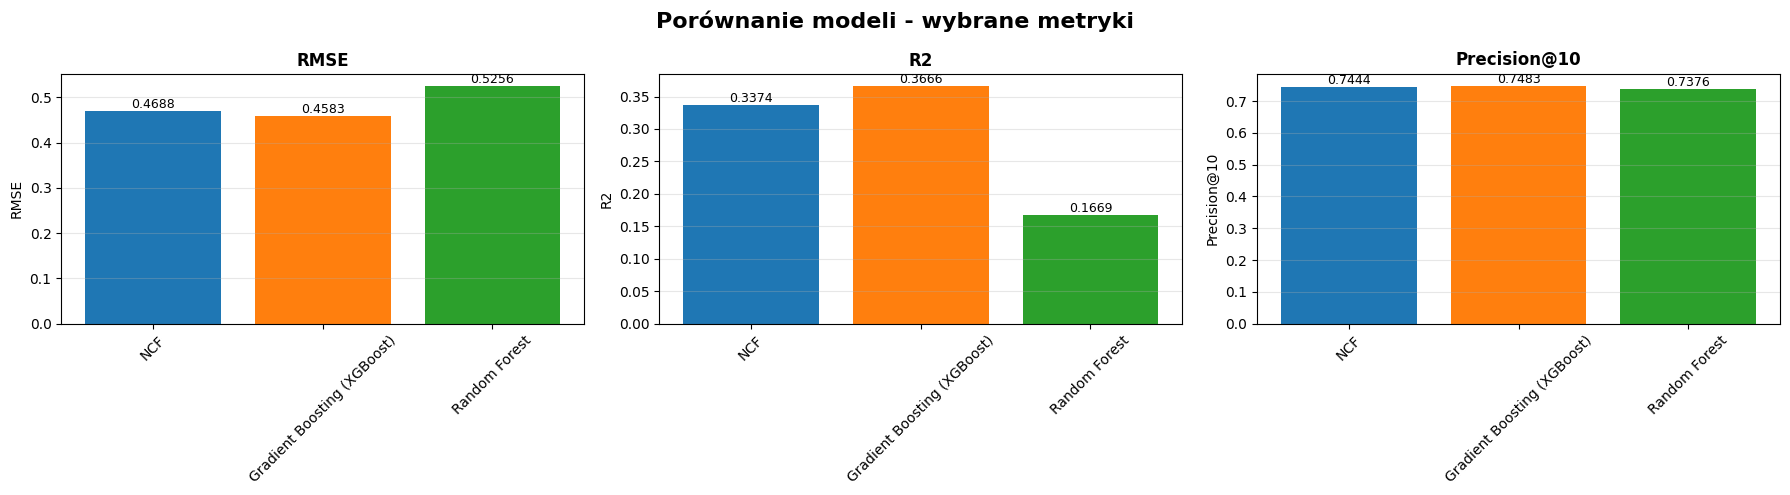

Wyniki zapisane do 'model_metrics.csv'


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Porównanie modeli - wybrane metryki', fontsize=16, fontweight='bold')

for idx, metric in enumerate(['RMSE', 'R2', 'Precision@10']):
    ax     = axes[idx]
    values = results_df[metric].values
    models = results_df.index.values
    bars   = ax.bar(models, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("Wykres zapisany jako 'model_comparison.png'")
plt.show()

results_df.to_csv('model_metrics.csv')
print("Wyniki zapisane do 'model_metrics.csv'")